In [5]:
# Imports básicos
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
import os
from sklearn.metrics import mean_squared_error

In [7]:
# Busca o último CSV exportado pelo SAARIS no diretório atual
arquivos_csv = [f for f in os.listdir('.') if f.startswith('saaris_export') and f.endswith('.csv')]

if not arquivos_csv:
    print("ERRO: Nenhum arquivo CSV do SAARIS encontrado.")
    print("Faça o upload do arquivo gerado pelo simulador antes de rodar a análise.")
else:
    caminho_arquivo = arquivos_csv[-1]
    print(f"Lendo dados de: {caminho_arquivo}")

    # Carrega os dados e limpa os valores nulos do simulador (-200 dBm = sem sinal)
    df = pd.read_csv(caminho_arquivo, sep=';')
    df_plot = df.replace(-200.00, np.nan)

Lendo dados de: saaris_export_2026-04-17T14-08-27.csv


In [8]:
# Implementação do modelo teórico: ITU-R P.526 + Log-Distance (Path Loss)
def get_theoretical(dist_range):
    # Parâmetros base da simulação
    p_tx_dbm = 40.0
    freq_mhz = 2400.0
    h_tx = 30.0
    h_wall = 80.0
    x_wall = 149.1
    expoente_perda = 2.8

    lambda_m = 300.0 / freq_mhz
    d0 = 1.0
    l0 = 20 * math.log10(d0) + 20 * math.log10(freq_mhz) - 27.55

    theoretical_values = []
    for x in dist_range:
        # Cálculo da perda no espaço livre + ambiente
        d_total = math.sqrt(x**2 + h_tx**2)
        perda_ambiente = l0 + 10 * expoente_perda * math.log10(d_total / d0)

        # Cálculo da perda por difração no obstáculo (Knife-edge)
        loss_diff = 0.0
        if x > x_wall:
            d1 = x_wall
            d2 = max(0.001, x - x_wall)
            y_los = h_tx * (d2 / (d1 + d2))
            h_eff = h_wall - y_los
            v = h_eff * math.sqrt(2 * (d1 + d2) / (lambda_m * d1 * d2))

            if v > -0.7:
                loss_diff = 6.9 + 20 * math.log10(math.sqrt((v-0.1)**2 + 1) + v - 0.1)

        theoretical_values.append(p_tx_dbm - perda_ambiente - loss_diff)

    return theoretical_values

if arquivos_csv:
    theory = get_theoretical(df['dist_m'].values)

RMSE da Validação: 0.76 dB



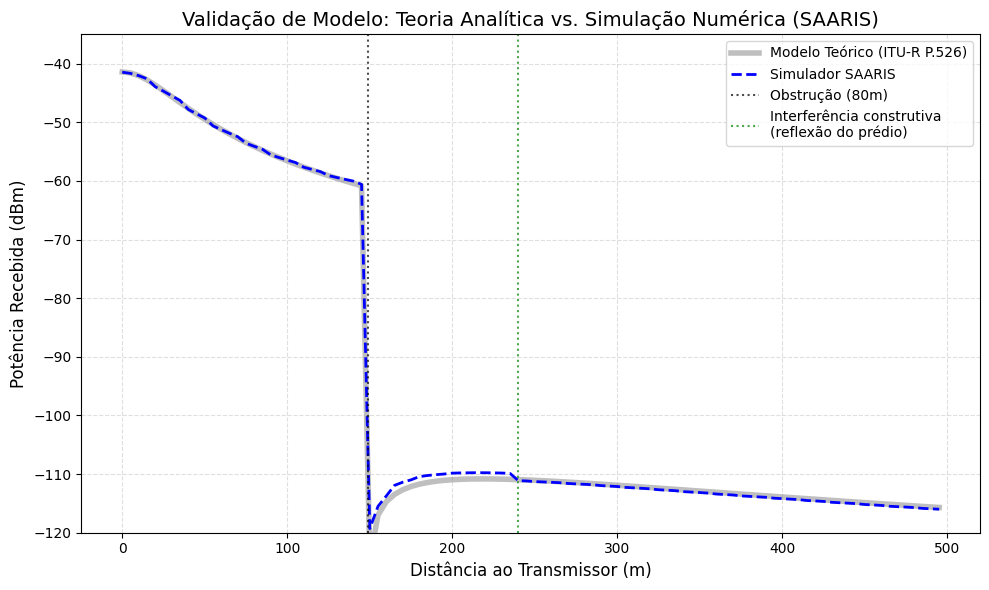

In [10]:
# Geração do gráfico comparativo
if arquivos_csv:
    valid_sim = df['p_total_dbm']
    valid_theory = np.array(theory)

    # Calcula o RMSE
    rmse = np.sqrt(mean_squared_error(valid_theory, valid_sim))
    print(f"RMSE da Validação: {rmse:.2f} dB\n")

    plt.figure(figsize=(10, 6))

    # Plota o modelo analítico e os dados do SAARIS
    plt.plot(df['dist_m'], theory, label='Modelo Teórico (ITU-R P.526)', color='grey', linewidth=4, alpha=0.5)
    plt.plot(df_plot['dist_m'], df_plot['p_total_dbm'], label='Simulador SAARIS', color='blue', linestyle='--', linewidth=2)

    # Marcações do cenário estrutural
    plt.axvline(x=149.1, color='black', linestyle=':', alpha=0.7, label='Obstrução (80m)')
    plt.axvline(x=240.1, color='green', linestyle=':', alpha=0.7, label='Interferência construtiva\n(reflexão do prédio)')

    # Formatação
    plt.title('Validação de Modelo: Teoria Analítica vs. Simulação Numérica (SAARIS)', fontsize=14)
    plt.xlabel('Distância ao Transmissor (m)', fontsize=12)
    plt.ylabel('Potência Recebida (dBm)', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, which='both', linestyle='--', alpha=0.4)
    plt.ylim(-120, -35)

    plt.tight_layout()
    plt.savefig('validacao_final_saaris.pdf')
    plt.show()